在这个工作是是将航班频次作为边的权重

# 加载数据

In [1]:
import pandas as pd
# 加载数据
# data = pd.read_csv('../my/hh_result/result_all.csv', dtype={'flt_no': str})
# data_24 = pd.read_csv('../my/hh_result/result_24_7-10.csv', dtype={'flt_no': str})
data = pd.read_csv('./data_with_competitor_prices.csv', dtype={'flt_no': str})

# 查看前几行数据，确保加载成功
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1564130 entries, 0 to 1564129
Data columns (total 20 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   flt_no            1564130 non-null  object 
 1   cap               1564130 non-null  int64  
 2   aircraft          1564130 non-null  object 
 3   legs              1564130 non-null  int64  
 4   leg_no            1564130 non-null  int64  
 5   duration          1563751 non-null  float64
 6   pax               1564130 non-null  int64  
 7   a                 1564130 non-null  object 
 8   b                 1564130 non-null  object 
 9   c                 648662 non-null   object 
 10  unit_price        1564130 non-null  float64
 11  competitor_price  1564130 non-null  float64
 12  year              1564130 non-null  int64  
 13  month             1564130 non-null  int64  
 14  day               1564130 non-null  int64  
 15  weekday           1564130 non-null  int64  
 16  

## 统计不同城市的频率

In [2]:
# 将 from 和 to 两列合并，并统计每个城市的出现次数
city_count_series = pd.concat([data['from'], data['to']]).value_counts()

# 转换为 city_count 数据框
city_count = city_count_series.reset_index()
city_count.columns = ['city', 'count']

# 3. 创建 city_map，将每个城市映射为其出现次数（或者任何你需要的值）
city_map = dict(zip(city_count['city'], city_count['count']))

# 输出结果
print(city_count)

    city   count
0    HAK  201975
1    XIY  168047
2    CKG  126743
3    PEK  121463
4    URC  119514
..   ...     ...
196  LLB     124
197  JNZ      92
198  KJH      77
199  XNT      54
200  ZHY      47

[201 rows x 2 columns]


In [3]:
import json

# 保存 city_map 到 JSON 文件
with open('../../my/encoder/city_map_频率编码.json', 'w') as f:
    json.dump(city_map, f)

print("city_map_频率编码 已保存到 city_map_频率编码")

city_map_频率编码 已保存到 city_map_频率编码


### 'flt_no', 'bd_type', 'aircraft'编码

In [4]:
import joblib
from sklearn.preprocessing import LabelEncoder
import os

# 定义需要编码的分类特征
# categorical_columns = ['flt_no', 'bd_type', 'aircraft', 'a', 'b', 'c', 'from', 'to']
# categorical_columns = ['flt_no', 'bd_type', 'aircraft']
categorical_columns = ['flt_no', 'aircraft']


# 创建并应用 LabelEncoder
label_encoders = {}

# 创建保存编码器的文件夹（如果文件夹不存在）
save_folder = '../../my/encoder/'
os.makedirs(save_folder, exist_ok=True)  # 如果文件夹已存在，不会报错

# 遍历每个分类特征，使用 LabelEncoder 对其进行编码
for col in categorical_columns:
    le = LabelEncoder()  # 创建一个 LabelEncoder 实例
    data[col] = le.fit_transform(data[col])  # 对训练数据中的分类特征进行编码
    label_encoders[col] = le  # 将每个特征的编码器保存到字典中，方便后续使用

    # 保存每个编码器到指定文件夹
    encoder_path = os.path.join(save_folder, f"{col}_encoder_all.pkl")  # 构建保存路径
    joblib.dump(le, encoder_path)  # 使用 joblib 将编码器保存为 pkl 文件
    print(f"{col} 的编码器已保存为 {encoder_path}")  # 输出保存的路径

flt_no 的编码器已保存为 ../../my/encoder/flt_no_encoder_all.pkl
aircraft 的编码器已保存为 ../../my/encoder/aircraft_encoder_all.pkl


## 生成加权图

In [5]:
# 创建一个新的数据框，用于存储航班频数
flight_counts = data.groupby(['from', 'to']).size().reset_index(name='flight_count')

# 打印查看
print(flight_counts.shape)
print(flight_counts.head())


(3257, 3)
  from   to  flight_count
0  AAT  CKG            56
1  AAT  PEK            31
2  AAT  TCG            14
3  AAT  URC           518
4  AAT  XIY           168


In [6]:
import networkx as nx

# 创建一个空图
G = nx.Graph()

# 将城市作为节点，航班频数作为边的权重添加到图中
for index, row in flight_counts.iterrows():
    G.add_edge(row['from'], row['to'], weight=row['flight_count'])

# 输出图的基本信息
print("图的节点数:", G.number_of_nodes())
print("图的边数:", G.number_of_edges())

图的节点数: 201
图的边数: 1636


/opt/data/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/data/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/data/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 33322 (\N{CJK UNIFIED IDEOGRAPH-822A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/data/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 29677 (\N{CJK UNIFIED IDEOGRAPH-73ED}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/data/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 32593 (\N{CJK UNIFIED IDE

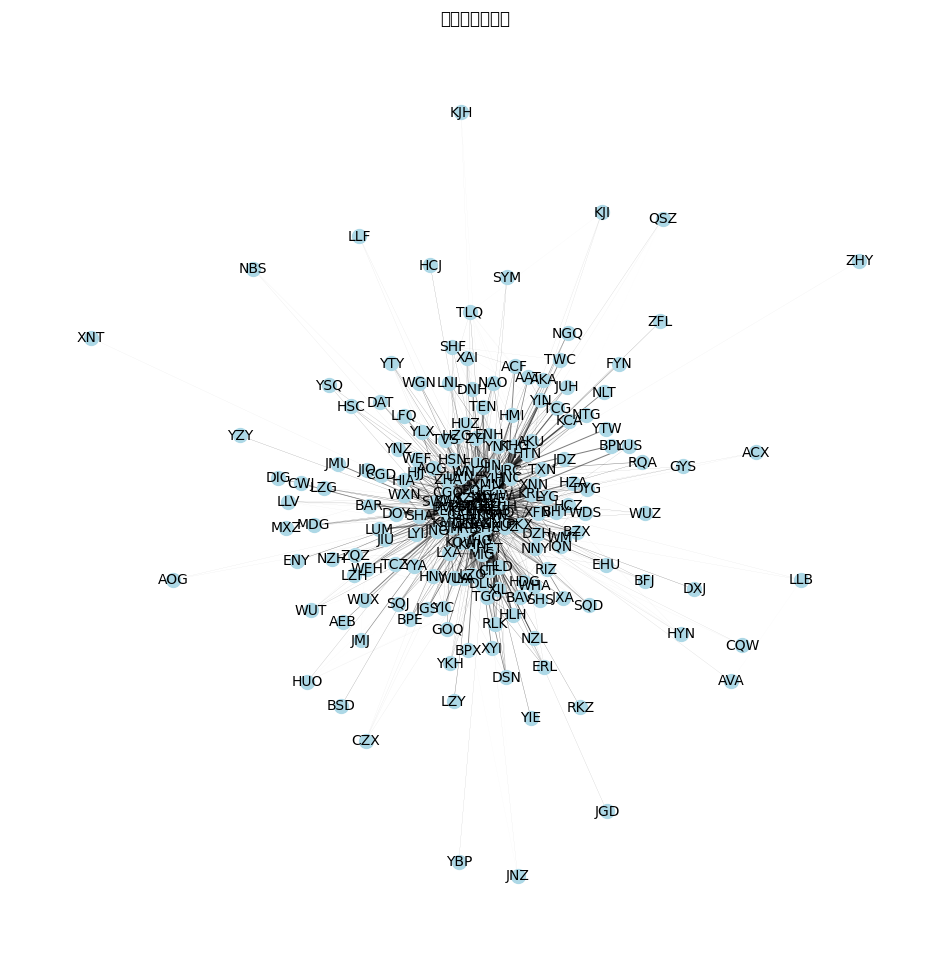

In [7]:
import matplotlib.pyplot as plt

# 设置图的布局
plt.figure(figsize=(12, 12))

# 绘制加权图，边的宽度表示航班频数
pos = nx.spring_layout(G, k=0.5)  # 使用 spring 布局来可视化图
edges = G.edges(data=True)

# 绘制节点
nx.draw_networkx_nodes(G, pos, node_size=100, node_color='lightblue')

# 绘制边，边的宽度表示航班频数（weight）
nx.draw_networkx_edges(G, pos, width=[d['weight'] / 1000 for u, v, d in edges], alpha=0.5)

# 绘制节点标签
nx.draw_networkx_labels(G, pos, font_size=10)

# 显示图形
plt.title("加权航班网络图")
plt.axis('off')
plt.show()

## 创建并训练 DeepWalk 模型

In [8]:
import numpy
print(numpy.__version__)

1.24.4


In [9]:
import networkx as nx
from node2vec import Node2Vec

/opt/data/envs/machine/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1. 加载图并准备数据

In [10]:
node2vec = Node2Vec(G, 
                   dimensions=64, 
                   walk_length=3, 
                   num_walks=2000, 
                   workers=4,
                   weight_key='weight')

model = node2vec.fit(window=3, 
                    min_count=1, 
                    batch_words=4)

Generating walks (CPU: 4): 100%|██████████| 500/500 [00:02<00:00, 229.83it/s]


2. 获取节点的嵌入向量

In [11]:
# 获取城市嵌入表示
city_embeddings = {}
for city in G.nodes():
    city_embeddings[city] = model.wv[city]  # 从模型中提取城市嵌入

# 打印第一个城市的嵌入表示
print(city_embeddings[list(G.nodes())[0]])

[ 0.33265033 -0.27806583  0.56810117 -0.08221889  0.18719347 -0.49182636
  0.24741109 -0.11767506 -0.4671328  -0.35264596  0.25676903 -0.5394778
  0.13935484 -0.20149441 -0.1044814   0.59026515 -0.67896587  0.19263482
  0.52487785  0.5363086  -0.24861243  0.42627025  0.29543847 -0.54210025
  0.67808574 -0.06332122  0.07733678  0.55236584  0.23870042 -0.13643532
  0.12728263 -0.0276217   0.34191826 -0.18653299 -0.25683728  0.18168381
 -0.01139939  0.27733898  0.18130574  0.13464424  0.03530204  0.32976517
 -0.19030917  0.00455428  0.19233918 -0.20451339  0.01648388  0.06915759
  0.1324575   0.44073176  0.29228702  0.42152148  0.0804643   0.37760168
  0.00512877 -0.15298273  0.07928656 -0.14778854  0.03506935  0.10618806
  0.40898    -0.3173018  -0.10443693 -0.48114553]


city_embeddings是一个字典

## 进行聚类

步骤 3：使用嵌入向量进行下游任务（例如聚类）

In [12]:
from sklearn.cluster import KMeans
import numpy as np

# 提取嵌入向量
embeddings = np.array([city_embeddings[city] for city in G.nodes()])

# 使用 KMeans 聚类
kmeans = KMeans(n_clusters=3, random_state=42)  # 设置簇的数量为3
kmeans.fit(embeddings)

# 查看每个城市的聚类标签
city_labels = dict(zip(G.nodes(), kmeans.labels_))

# 打印城市及其对应的聚类标签
for city, label in city_labels.items():
    print(f"城市: {city}, 聚类标签: {label}")


城市: AAT, 聚类标签: 2
城市: CKG, 聚类标签: 0
城市: PEK, 聚类标签: 0
城市: TCG, 聚类标签: 2
城市: URC, 聚类标签: 2
城市: XIY, 聚类标签: 0
城市: YIN, 聚类标签: 2
城市: ACF, 聚类标签: 2
城市: HMI, 聚类标签: 2
城市: SHF, 聚类标签: 2
城市: TLQ, 聚类标签: 2
城市: ACX, 聚类标签: 1
城市: CGO, 聚类标签: 0
城市: KMG, 聚类标签: 0
城市: AEB, 聚类标签: 1
城市: CAN, 聚类标签: 0
城市: HGH, 聚类标签: 0
城市: KWL, 聚类标签: 0
城市: TFU, 聚类标签: 0
城市: AKA, 聚类标签: 1
城市: HAK, 聚类标签: 0
城市: TSN, 聚类标签: 0
城市: UYN, 聚类标签: 0
城市: AKU, 聚类标签: 2
城市: FOC, 聚类标签: 0
城市: HTN, 聚类标签: 2
城市: AOG, 聚类标签: 0
城市: TNA, 聚类标签: 0
城市: AQG, 聚类标签: 0
城市: KWE, 聚类标签: 0
城市: NGB, 聚类标签: 0
城市: TAO, 聚类标签: 0
城市: XMN, 聚类标签: 0
城市: AVA, 聚类标签: 0
城市: LLB, 聚类标签: 0
城市: BAR, 聚类标签: 1
城市: HRB, 聚类标签: 0
城市: JMJ, 聚类标签: 1
城市: KHN, 聚类标签: 0
城市: LHW, 聚类标签: 0
城市: SJW, 聚类标签: 0
城市: SZX, 聚类标签: 0
城市: BAV, 聚类标签: 0
城市: HLD, 聚类标签: 1
城市: TGO, 聚类标签: 1
城市: XIL, 聚类标签: 1
城市: BFJ, 聚类标签: 0
城市: NNG, 聚类标签: 0
城市: BHY, 聚类标签: 0
城市: HFE, 聚类标签: 0
城市: JNG, 聚类标签: 0
城市: NAO, 聚类标签: 2
城市: WUH, 聚类标签: 0
城市: XUZ, 聚类标签: 0
城市: YIH, 聚类标签: 0
城市: BPE, 聚类标签: 0
城市: CSX, 聚类标签: 0
城市: BPL, 聚类标签: 2
城市: BPX, 聚类标签:

### 保存聚类标签

In [13]:
# 首先导入 json 模块
import json
print(city_labels)

# 将字典中的所有值转换为 Python 的原生 int 类型
city_labels = {key: int(value) for key, value in city_labels.items()}

# 保存字典到 JSON 文件
with open('../../my/encoder/city_labels_航班频率加权图标签.json', 'w') as file:
    json.dump(city_labels, file)

print("字典已保存为 city_labels.json")

{'AAT': 2, 'CKG': 0, 'PEK': 0, 'TCG': 2, 'URC': 2, 'XIY': 0, 'YIN': 2, 'ACF': 2, 'HMI': 2, 'SHF': 2, 'TLQ': 2, 'ACX': 1, 'CGO': 0, 'KMG': 0, 'AEB': 1, 'CAN': 0, 'HGH': 0, 'KWL': 0, 'TFU': 0, 'AKA': 1, 'HAK': 0, 'TSN': 0, 'UYN': 0, 'AKU': 2, 'FOC': 0, 'HTN': 2, 'AOG': 0, 'TNA': 0, 'AQG': 0, 'KWE': 0, 'NGB': 0, 'TAO': 0, 'XMN': 0, 'AVA': 0, 'LLB': 0, 'BAR': 1, 'HRB': 0, 'JMJ': 1, 'KHN': 0, 'LHW': 0, 'SJW': 0, 'SZX': 0, 'BAV': 0, 'HLD': 1, 'TGO': 1, 'XIL': 1, 'BFJ': 0, 'NNG': 0, 'BHY': 0, 'HFE': 0, 'JNG': 0, 'NAO': 2, 'WUH': 0, 'XUZ': 0, 'YIH': 0, 'BPE': 0, 'CSX': 0, 'BPL': 2, 'BPX': 0, 'BSD': 1, 'BZX': 0, 'LJG': 0, 'NKG': 0, 'CGQ': 0, 'DLC': 0, 'DOY': 1, 'HDG': 0, 'HET': 0, 'HSN': 0, 'HZG': 2, 'INC': 0, 'JIQ': 0, 'PKX': 0, 'PVG': 0, 'SHA': 0, 'SHE': 0, 'SQJ': 0, 'SYX': 0, 'TEN': 0, 'TYN': 0, 'WEF': 0, 'WUA': 1, 'YIC': 0, 'ZQZ': 0, 'CGD': 0, 'JHG': 0, 'CIF': 0, 'DLU': 1, 'ENH': 0, 'GOQ': 2, 'HNY': 0, 'HUZ': 0, 'JGS': 0, 'JJN': 0, 'JNZ': 1, 'KCA': 2, 'KHG': 2, 'KOW': 0, 'KRL': 2, 'LXA': 0,

## 二维空间聚类效果展示

步骤 4：可视化嵌入

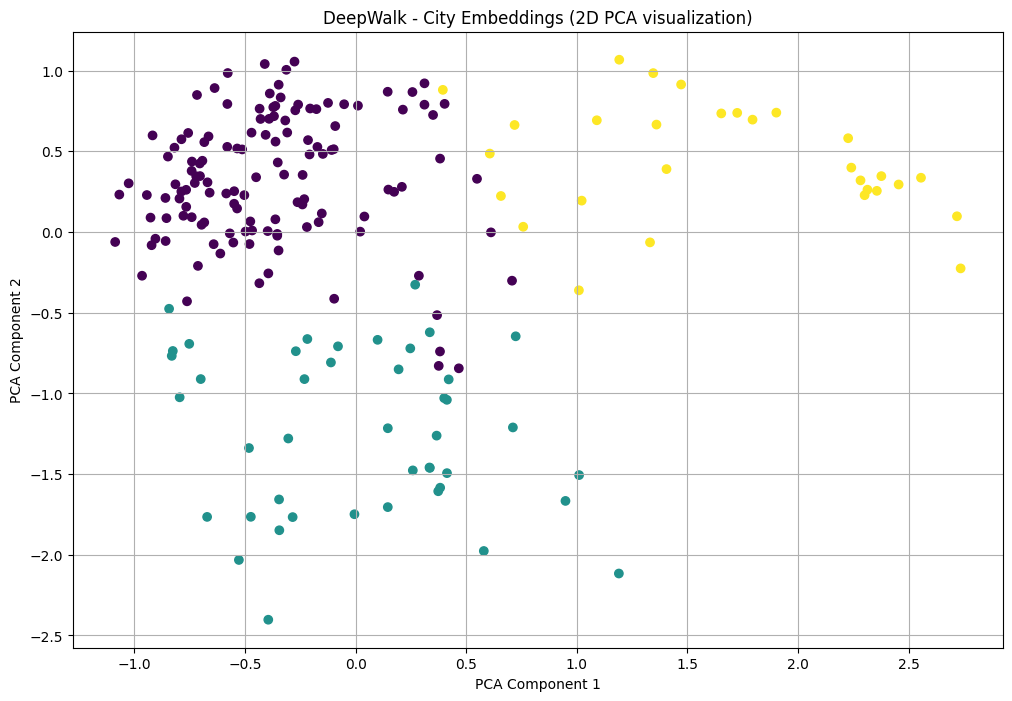

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 使用 PCA 降维到 2D
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# 绘制散点图
plt.figure(figsize=(12, 8))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=kmeans.labels_, cmap='viridis')

# 去掉为每个城市添加标签的部分
# for i, city in enumerate(G.nodes()):
#     plt.text(reduced_embeddings[i, 0] + 0.1, reduced_embeddings[i, 1] + 0.1, city, fontsize=9)

plt.title("DeepWalk - City Embeddings (2D PCA visualization)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()


In [15]:
from sklearn.metrics.pairwise import cosine_similarity

# 计算城市之间的相似度
similarity_matrix = cosine_similarity(embeddings)

# 打印第一个城市和其他城市的相似度
for i, city in enumerate(G.nodes()):
    print(f"城市: {city}, 相似度: {similarity_matrix[0, i]}")

城市: AAT, 相似度: 0.9999997615814209
城市: CKG, 相似度: 0.10252031683921814
城市: PEK, 相似度: 0.15840227901935577
城市: TCG, 相似度: 0.8551876544952393
城市: URC, 相似度: 0.5705220103263855
城市: XIY, 相似度: 0.28991079330444336
城市: YIN, 相似度: 0.7213472723960876
城市: ACF, 相似度: 0.6271737217903137
城市: HMI, 相似度: 0.44640815258026123
城市: SHF, 相似度: 0.3913353979587555
城市: TLQ, 相似度: 0.5312783122062683
城市: ACX, 相似度: 0.20119749009609222
城市: CGO, 相似度: 0.14013069868087769
城市: KMG, 相似度: 0.08501801639795303
城市: AEB, 相似度: 0.17633958160877228
城市: CAN, 相似度: 0.21204814314842224
城市: HGH, 相似度: 0.11444437503814697
城市: KWL, 相似度: 0.07005579024553299
城市: TFU, 相似度: 0.11178741604089737
城市: AKA, 相似度: 0.16063731908798218
城市: HAK, 相似度: 0.11070730537176132
城市: TSN, 相似度: 0.168772891163826
城市: UYN, 相似度: 0.29414433240890503
城市: AKU, 相似度: 0.5395196080207825
城市: FOC, 相似度: 0.1551671177148819
城市: HTN, 相似度: 0.5039125680923462
城市: AOG, 相似度: 0.18483424186706543
城市: TNA, 相似度: 0.22144295275211334
城市: AQG, 相似度: 0.11536436527967453
城市: KWE, 相似度: 0.1452049016

轮廓系数是评估聚类质量的常用指标，范围是 -1 到 1，值越大表示聚类效果越好。它同时考虑了簇内紧密度（每个点与所在簇中其他点的距离）和簇间分离度（每个点与最近簇的距离）。

值的意义：

值接近 +1：说明数据点与同簇内的点很接近，且与其他簇的点有很大区别，聚类效果好。

值接近 0：表示数据点可能位于两个簇的边界上，聚类效果一般。

值接近 -1：表示数据点可能被错误地归类到某个簇中，聚类效果差。

In [16]:
from sklearn.metrics import silhouette_score
score = silhouette_score(reduced_embeddings, kmeans.labels_)
print(f'Silhouette Score: {score}')

Silhouette Score: 0.5169491171836853


## 保存嵌入表示

In [17]:
import numpy as np
import json

# 获取城市列表
cities = list(city_embeddings.keys())

# 将降维后的嵌入表示转换为列表格式
reduced_embeddings_list = reduced_embeddings.tolist()

# 保存城市和其对应的嵌入（将 NumPy 数组转换为列表）
city_embedding_dict = {city: reduced_embeddings[i].tolist() for i, city in enumerate(cities)}

# 将 city_embedding_dict 保存为 JSON 文件
with open('../../my/encoder/城市嵌入编码_航班频率加权图.json', 'w') as f:
    json.dump(city_embedding_dict, f)

print("城市嵌入表示已保存。")

城市嵌入表示已保存。


In [18]:
city_embedding_dict

{'AAT': [1.3597848415374756, 0.6660159826278687],
 'CKG': [-0.0919976532459259, 0.6568402051925659],
 'PEK': [-0.2624581456184387, 0.18506205081939697],
 'TCG': [1.3452502489089966, 0.9850115776062012],
 'URC': [1.191598653793335, 1.0679560899734497],
 'XIY': [-0.5777866840362549, 0.9855008721351624],
 'YIN': [1.9014595746994019, 0.7400669455528259],
 'ACF': [1.4711376428604126, 0.9144527316093445],
 'HMI': [0.39429816603660583, 0.8812238574028015],
 'SHF': [1.0217688083648682, 0.19476288557052612],
 'TLQ': [0.6065776944160461, 0.4862461984157562],
 'ACX': [0.7235668301582336, -0.6459048390388489],
 'CGO': [0.25691214203834534, 0.8677778244018555],
 'KMG': [-0.3540305197238922, -0.0116242291405797],
 'AEB': [0.7109003663063049, -1.2106705904006958],
 'CAN': [-0.09886128455400467, 0.5134572982788086],
 'HGH': [-0.2080717533826828, 0.4809180498123169],
 'KWL': [-0.9176110625267029, 0.5989621877670288],
 'TFU': [0.17415915429592133, 0.24932153522968292],
 'AKA': [-0.07954857498407364, -0.